In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


In [4]:
df.shape

(1340, 10)

In [5]:
pd.set_option("display.float_format","{:.2f}".format)

In [6]:
sns.set(style="whitegrid", palette="Set2", font_scale=1.1)

In [7]:
df.duplicated().sum()

0

In [8]:
df.isna().sum().sum() 
# Since there is only 8 out of 1340 values 
# that have no value, we can just drop them 
# and not lose much info. 

8

In [9]:
df.dropna(inplace=True)

In [10]:
df.shape #dropped 8 values

(1332, 10)

In [11]:
df.isna().sum().sum() 

0

In [12]:
df.describe(include="all")

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,1332.00,1332.00,1332,1332.00,1332.00,1332,1332.00,1332,1332,1332.00
unique,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,670,NaN,NaN,695,NaN,1058,442,NaN
mean,674.47,38.09,NaN,30.66,94.19,NaN,1.10,NaN,NaN,13325.25
std,384.70,11.11,NaN,6.12,11.45,NaN,1.21,NaN,NaN,12109.62
min,1.00,18.00,NaN,16.00,80.00,NaN,0.00,NaN,NaN,1121.87
25%,341.75,29.00,NaN,26.20,86.00,NaN,0.00,NaN,NaN,4760.16
50%,674.50,38.00,NaN,30.35,92.00,NaN,1.00,NaN,NaN,9412.97
75%,1007.25,47.00,NaN,34.73,99.00,NaN,2.00,NaN,NaN,16781.33


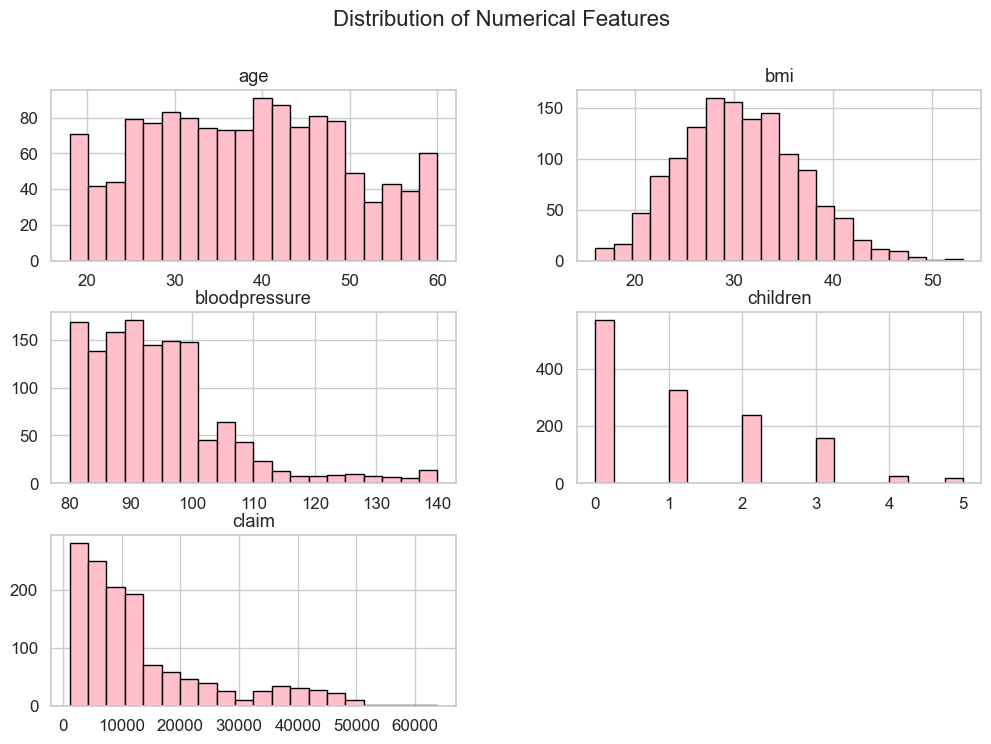

In [13]:
numeric_cols = ["age", "bmi", "bloodpressure", "children", "claim"]
df[numeric_cols].hist(bins= 20, figsize=(12,8), color="pink", edgecolor="black")
plt.suptitle("Distribution of Numerical Features", fontsize = 16)
plt.show()

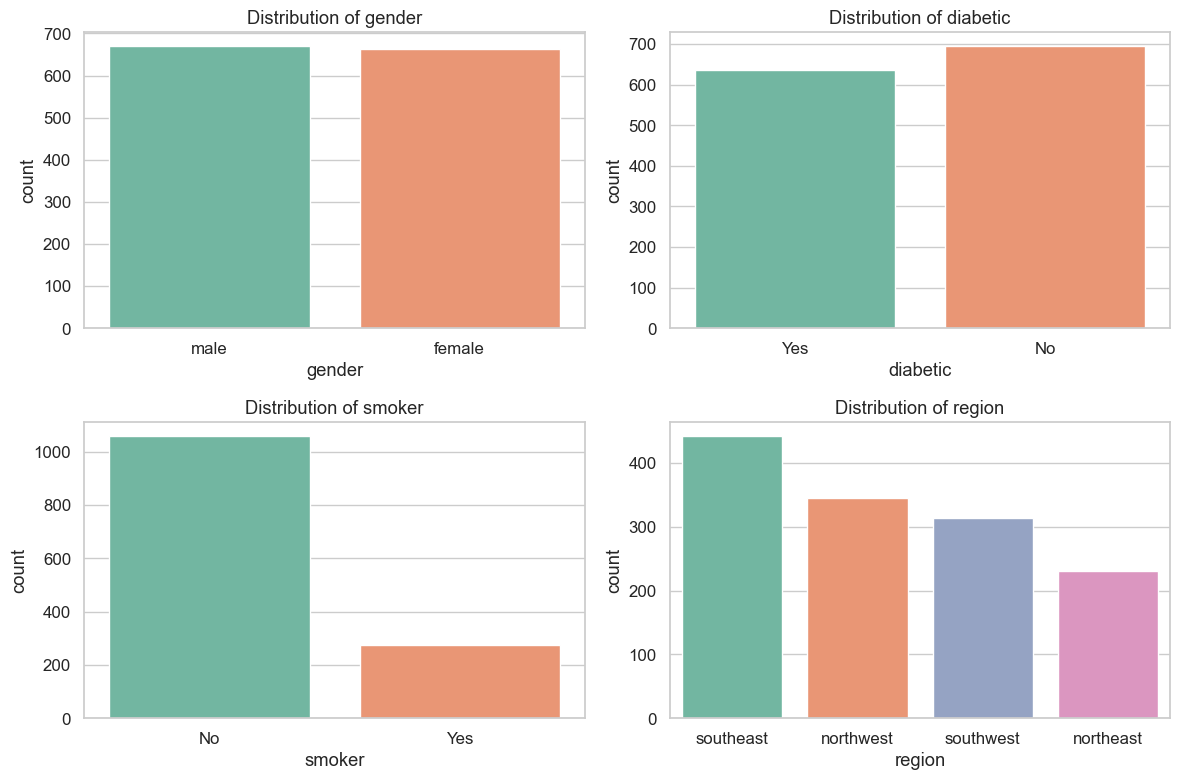

In [14]:
cat_cols = ["gender", "diabetic", "smoker", "region"]

plt.figure(figsize=(12,8))

for i, col in enumerate(cat_cols,1):
    plt.subplot(2,2,i)
    sns.countplot(data = df, x = col, hue = col, palette="Set2", legend = False) # newer version requires more arguments
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()


In [15]:
df.groupby(["gender", "smoker"])["claim"].mean().round(2)
# claims increase if they are smokers


gender  smoker
female  No        8762.30
        Yes      30679.00
male    No        8169.25
        Yes      33042.01
Name: claim, dtype: float64

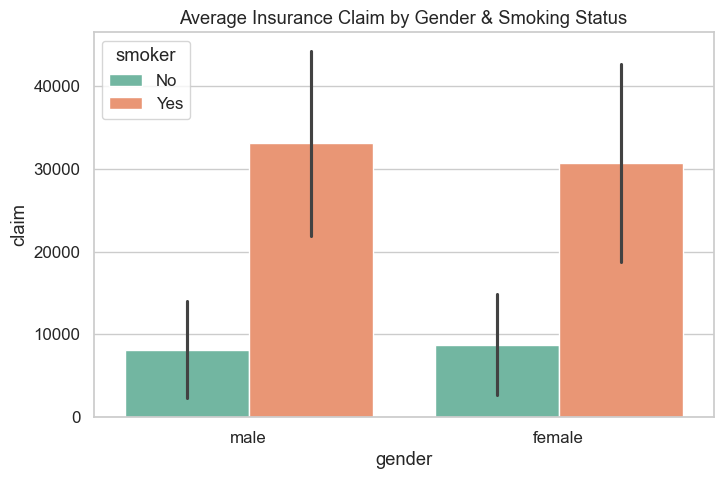

In [16]:
plt.figure(figsize=(8,5))
sns.barplot(data= df, x = "gender", y = "claim", hue = "smoker", estimator = "mean", errorbar = "sd")
plt.title("Average Insurance Claim by Gender & Smoking Status")
plt.show()
#Gender doesnt play much of a role in claims. 

In [17]:
pivot_region_diabetic = df.groupby(["region", "diabetic"])["claim"].mean().unstack()

In [18]:
pivot_region_diabetic

diabetic,No,Yes
region,,
northeast,16966.86,16818.30
northwest,11442.83,12224.96
southeast,13578.72,12574.09
southwest,13069.91,12313.74


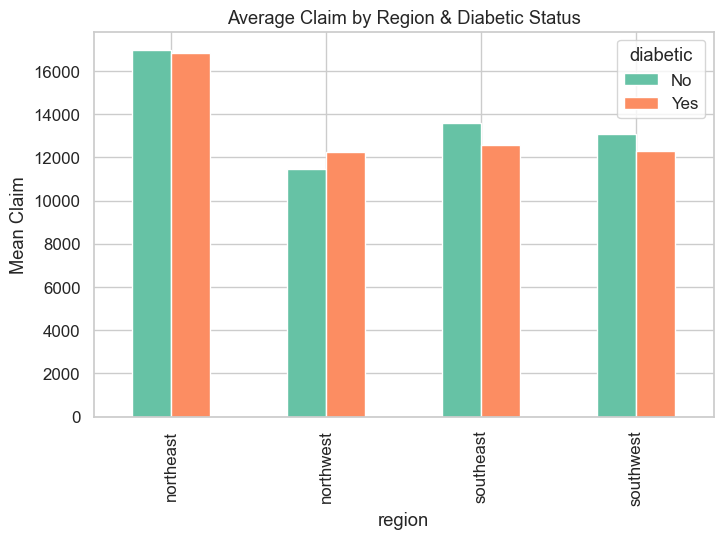

In [19]:
pivot_region_diabetic.plot(kind = "bar", figsize= (8,5))
plt.title("Average Claim by Region & Diabetic Status")
plt.ylabel("Mean Claim")
plt.show()
#diabetic is not really effective on insurance payment and the northeast leads in highest average claims 

In [20]:
pivot_table = pd.pivot_table(df, values = "claim", index= "region", columns="smoker", aggfunc = "mean")
pivot_table
#claim increases if they are smoker

smoker,No,Yes
region,,
northeast,11666.11,29673.54
northwest,8076.20,30192.00
southeast,7444.14,34845.00
southwest,8294.75,32269.06


In [21]:
pivot_table = pd.pivot_table(df, values = "claim",  index = "children", columns="diabetic", aggfunc = "mean")
pivot_table
#from the table it proves againthe diabetic is not a sole driver in claim outcome and the claim difference proves the hightest with 3 childrens

diabetic,No,Yes
children,,
0,12967.40,11985.29
1,12730.46,12732.06
2,15567.77,14579.36
3,13807.61,17091.26
4,14106.63,13573.35
5,8519.04,9205.59


In [22]:
numeric_cols

['age', 'bmi', 'bloodpressure', 'children', 'claim']

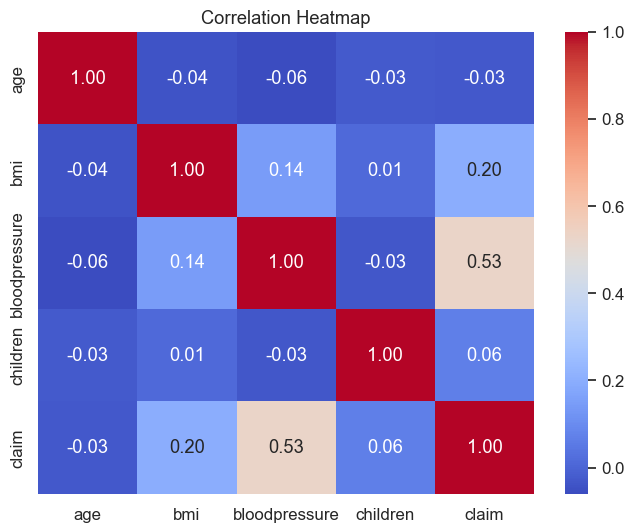

In [23]:
plt.figure(figsize = (8,6))
sns.heatmap(df[numeric_cols].corr(), annot = True, cmap = "coolwarm", fmt = ".2f")
plt.title("Correlation Heatmap")
plt.show()
# This heatmap shows a some moderate possitive correlation 
# between bloodpressure and claims, indicating that there might 
# be some correlation with increased bloodpressure and increased 
# claims, though there is not any strong correlation given from 
# this heat map as no values of r are reaching 1 or -1

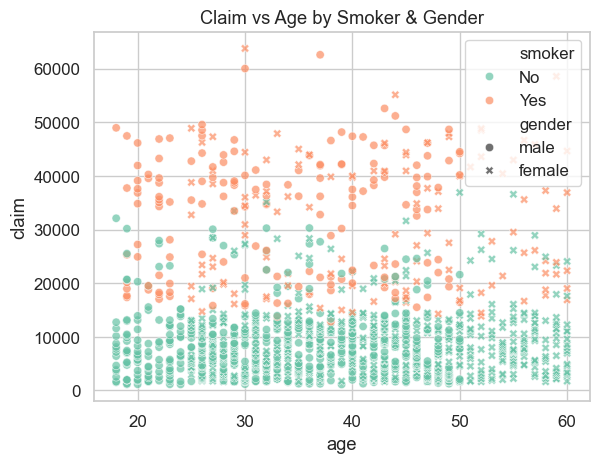

In [24]:
sns.scatterplot(data = df, x = "age", y = "claim", hue = "smoker", style = "gender", alpha = 0.7)
plt.title("Claim vs Age by Smoker & Gender")
plt.show()
#no gender base difference but again enhances point of higher claims for smokers. 

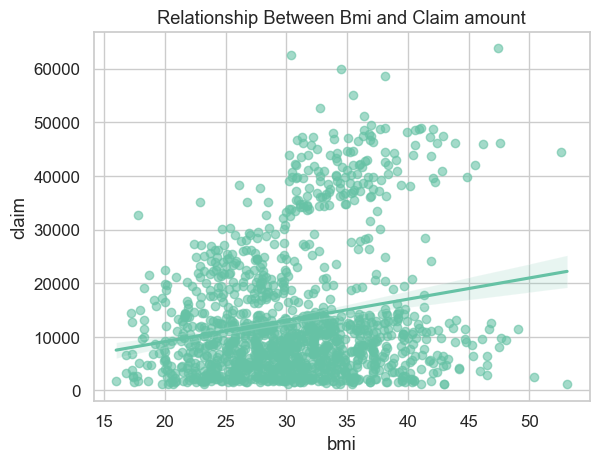

In [25]:
sns.regplot(data = df, x= "bmi", y = "claim", scatter_kws={"alpha":0.6})
plt.title("Relationship Between Bmi and Claim amount")
plt.show()
# graph shows the relationship between bmi and claim amount and demonstates an increase of BMI to increase a claims payment

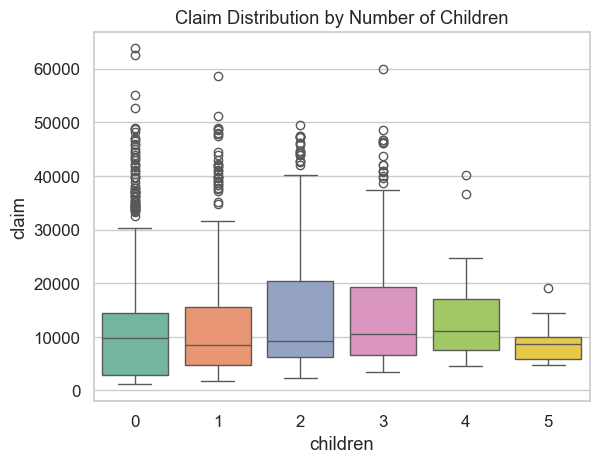

In [26]:
sns.boxplot(data = df, x = "children", y = "claim", hue = "children", palette="Set2", legend = False)
plt.title("Claim Distribution by Number of Children")
plt.show()

In [27]:
df["age_group"] = pd.cut(df["age"], bins = [0, 18, 30, 45, 60, 100], labels = ["<18", "18-30", "31-45", "46-60", "60+"])


In [28]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87,31-45
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51,18-30
7,8,19.00,male,41.10,100,No,0,No,northwest,1146.80,18-30
8,9,20.00,male,43.00,86,No,0,No,northwest,1149.40,18-30
9,10,30.00,male,53.10,97,No,0,No,northwest,1163.46,18-30
...,...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40,31-45
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07,46-60
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40,18-30
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87,31-45


In [29]:
df["age_group"].value_counts()

age_group
31-45    553
46-60    383
18-30    380
<18       16
60+        0
Name: count, dtype: int64

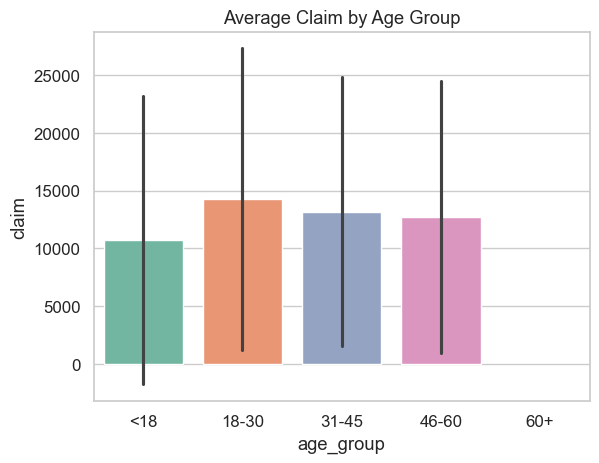

In [30]:
sns.barplot(data = df, x = "age_group", y = "claim", hue = "age_group", estimator="mean", errorbar="sd", palette="Set2", legend=False, dodge=False)
plt.title("Average Claim by Age Group")
plt.show()

In [31]:
df["bmi_category"] = pd.cut(df["bmi"], bins = [0, 18.5, 24.9, 29.9, 100], labels= ["Underweight", "Normal", "Overweight", "Obese"])


In [32]:
df["bmi_category"].value_counts()

bmi_category
Obese          702
Overweight     387
Normal         222
Underweight     21
Name: count, dtype: int64

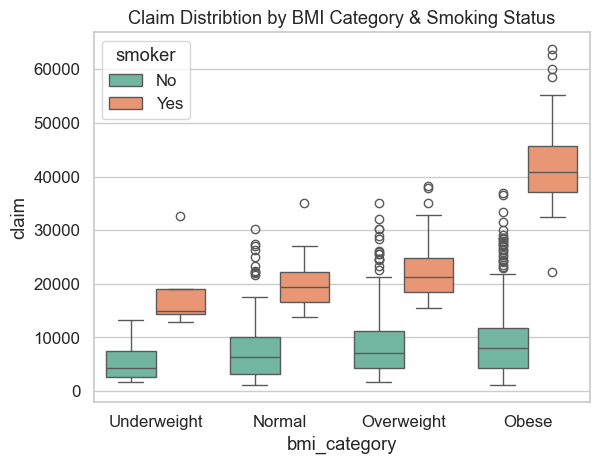

In [33]:
sns.boxplot(data = df, x = "bmi_category", y= "claim", hue= "smoker")
plt.title("Claim Distribtion by BMI Category & Smoking Status")
plt.show()
# Highest claims for this graph consists 
# of those who are smokers AND obese
# smoking itself increases claims regardless 
# but when paired with obesity, it increases claims

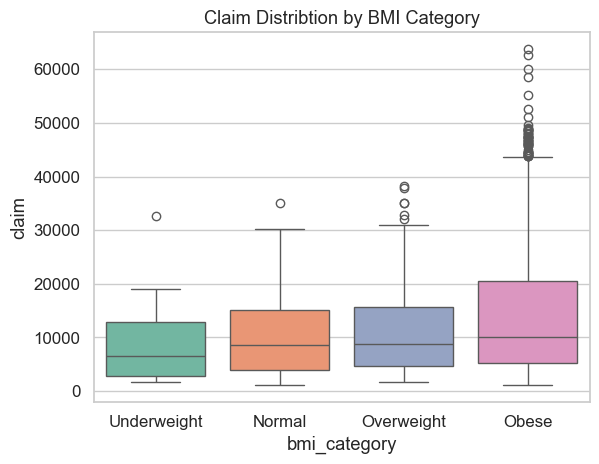

In [34]:
sns.boxplot(data = df, x = "bmi_category", y= "claim", hue = "bmi_category", palette="Set2")
plt.title("Claim Distribtion by BMI Category")
plt.show()

Feature Engineering 

In [35]:
region_stats = df.groupby("region").agg(
    smoker_rate = ("smoker", lambda x: (x=="Yes").mean()*100),
    mean_claim = ("claim", "mean")
).reset_index()


In [36]:
region_stats

,region,smoker_rate,mean_claim
0,northeast,29.00,16889.04
1,northwest,16.81,11794.22
2,southeast,20.59,13085.50
3,southwest,18.47,12723.13


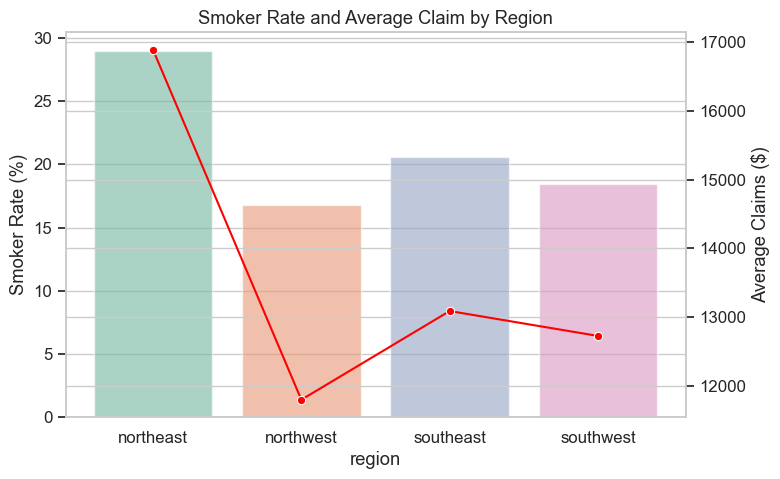

In [37]:
fig, ax1 = plt.subplots(figsize = (8,5))
sns.barplot(data = region_stats, x = "region", y = "smoker_rate", ax=ax1, alpha = 0.6, hue= "region", palette="Set2")
ax2 = ax1.twinx()
sns.lineplot(data = region_stats, x = "region", y = "mean_claim", ax = ax2, color = "red", marker = "o")

ax1.set_ylabel("Smoker Rate (%)")
ax2.set_ylabel("Average Claims ($)")
plt.title("Smoker Rate and Average Claim by Region")
plt.show()

# northeast have the highest avg claims and smoker rate % 
# in this data, while the northwest has least smoker rate % 
# and least avg claim cost 

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

In [39]:
df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim', 'age_group', 'bmi_category'],
      dtype='object')

In [40]:
X = df[["age", "gender", "bmi", "bloodpressure", "diabetic", "children", "smoker"]].copy()
y = df["claim"]

In [41]:
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.00,male,23.20,91,Yes,0,No
1,24.00,male,30.10,87,No,0,No
7,19.00,male,41.10,100,No,0,No
8,20.00,male,43.00,86,No,0,No
9,30.00,male,53.10,97,No,0,No
...,...,...,...,...,...,...,...
1335,44.00,female,35.50,88,Yes,0,Yes
1336,59.00,female,38.10,120,No,1,Yes
1337,30.00,male,34.50,91,Yes,3,Yes
1338,37.00,male,30.40,106,No,0,Yes


In [42]:
cat_cols = ["gender", "diabetic", "smoker"]
label_encoders = {}

In [43]:
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

    joblib.dump(le, f"label-encoder_{col}.pkl")

In [44]:
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.00,1,23.20,91,1,0,0
1,24.00,1,30.10,87,0,0,0
7,19.00,1,41.10,100,0,0,0
8,20.00,1,43.00,86,0,0,0
9,30.00,1,53.10,97,0,0,0
...,...,...,...,...,...,...,...
1335,44.00,0,35.50,88,1,0,1
1336,59.00,0,38.10,120,0,1,1
1337,30.00,1,34.50,91,1,3,1
1338,37.00,1,30.40,106,0,0,1


In [45]:
label_encoders

{'gender': LabelEncoder(),
 'diabetic': LabelEncoder(),
 'smoker': LabelEncoder()}

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2) 
# 80% of data is being used to train the model and 20% is to test it

In [47]:
num_cols = ["age", "bmi", "bloodpressure", "children"]
scaler = StandardScaler()

In [48]:
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [49]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [50]:
print(X_train.shape, y_train.shape)

(1065, 7) (1065,)


In [51]:
print(X_test.shape, y_test.shape)

(267, 7) (267,)


In [52]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [53]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return{ "R2" : r2, "MAE": mae, "RMSE": rmse}

In [54]:
results = {}

In [55]:
lr = LinearRegression()
lr.fit(X_train, y_train)
results["Linear Regression"] = evaluate_model(lr, X_train, X_test, y_train, y_test)
print("Linear Regression model trained")

best_poly_model = None
best_poly_score = -np.inf

for degree in [2,3]:
    poly = PolynomialFeatures(degree = degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    poly_lr = LinearRegression()
    poly_lr.fit(X_train_poly, y_train)

    score = poly_lr.score(X_test_poly, y_test)

    if score > best_poly_score:
        best_poly_score = score
        best_poly_model = (degree, poly, poly_lr)
    
degree, poly, poly_lr = best_poly_model

results[f"Polynomial Regression (deg = {degree})"] = evaluate_model(poly_lr, poly.fit_transform(X_train), poly.transform(X_test), y_train, y_test)

print("Polynomial Regression models are trained")

rf = RandomForestRegressor()

rf_params = {
    "n_estimators": [100, 200], 
    "max_depth": [None, 10, 20],
    "min_samples_split": [2,5],
    "min_samples_leaf": [1,2]
}

rf_grid = GridSearchCV(rf, rf_params, cv = 3, scoring= "r2", n_jobs= -1, verbose=0)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

results["Random Forest"] = evaluate_model(best_rf, X_train, X_test, y_train, y_test)

print("Random Forest training is completed, best parameterts:", rf_grid.best_params_)

svr = SVR()

svr_params = {
    "kernel": ["rbf", "poly", "linear"],
    "C": [1, 10, 50],
    "epsilon": [0.1, 0.2, 0.5],
    "degree": [2,3]
}

svr_grid = GridSearchCV(svr, svr_params, cv=3, scoring = "r2", n_jobs=-1, verbose=0)
svr_grid.fit(X_train, y_train)

best_svr = svr_grid.best_estimator_

results["SVR"] = evaluate_model(best_svr, X_train, X_test, y_train, y_test)

print("SVR training is completed, best parameters:", svr_grid.best_params_)

xgb = XGBRegressor(objective="reg:squarederror")

xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3,5,7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

xgb_grid = GridSearchCV(xgb, xgb_params, cv = 3, scoring = "r2", n_jobs = -1, verbose=0)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_

results["XGBoost"] = evaluate_model(best_xgb, X_train, X_test, y_train, y_test)

print("XGBoost training is completed, best parameters:", xgb_grid.best_params_)

Linear Regression model trained
Polynomial Regression models are trained
Random Forest training is completed, best parameterts: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
SVR training is completed, best parameters: {'C': 50, 'degree': 2, 'epsilon': 0.1, 'kernel': 'linear'}
XGBoost training is completed, best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [56]:
results

{'Linear Regression': {'R2': 0.7173284845496559,
  'MAE': 4827.712543092651,
  'RMSE': 6349.021717871485},
 'Polynomial Regression (deg = 3)': {'R2': 0.7996014120045971,
  'MAE': 4076.1107611833977,
  'RMSE': 5345.805058578597},
 'Random Forest': {'R2': 0.8289334610034225,
  'MAE': 3782.2886183068463,
  'RMSE': 4939.105734410677},
 'SVR': {'R2': 0.5481699745455537,
  'MAE': 5466.472987175037,
  'RMSE': 8027.001292160866},
 'XGBoost': {'R2': 0.8266646072504718,
  'MAE': 3782.0087926468864,
  'RMSE': 4971.751500209354}}

In [57]:
results_df = pd.DataFrame(results).T.sort_values(by = "R2", ascending = False)
results_df

,R2,MAE,RMSE
Random Forest,0.83,3782.29,4939.11
XGBoost,0.83,3782.01,4971.75
Polynomial Regression (deg = 3),0.80,4076.11,5345.81
Linear Regression,0.72,4827.71,6349.02
SVR,0.55,5466.47,8027.00


R2 (Coefficient of Determination): repersents the porportion of the variance in the insurance claims that is predicted from the input factors. It measures the model's "goodness of fit" by indicating how well the predictions match the actual data, with values closer to 1 signifying a better fit.

MAE (Mean of Absolute Errors): repersents the average of the absolute differences between predicted values and actual values. It signifies in this case on average how many dollars the prediction is off by.

RMSE (Root Mean Square Error): is similar to MAE but it squares the errors before averaging them resulting in a pentalization of large errors more heavily. It is essentially the standard deviation of the residuals. 

XGBoost: This model builds decision trees sequentially. Each new tree tries to correct the errors made by the previous ones. It is highly efficient and usually the "gold standard" for tabular data (like insurance spreadsheets).

Random Forest: This builds many independent decision trees and averages their results. It is excellent for insurance data because it handles "non-linear" relationships well (e.g., the way insurance costs don't just go up linearly with age, but might spike for smokers).

Polynomial Regression (deg=2): This is a version of linear regression that looks for curves rather than straight lines. Since insurance costs often have a curved relationship with things like BMI or age, it performs better (0.79) than standard linear regression.

Linear Regression: This assumes a straight-line relationship (e.g., "for every year you age, your premium goes up by exactly $X"). Because the real world is more complex, it only explains 70% of the data.

SVR (Support Vector Regression): SVR tries to fit the error within a specific threshold. Its poor performance here (0.49) suggests that either the data was not scaled properly (SVR is very sensitive to feature scales) or the relationship in the data is too complex for the chosen kernel.

Best model for this project: XGBoost because allthough it is ties for the highest R2, it provides the most stable predictions with a lower RMSE.


In [58]:
models = {
    "Linear Regression": lr,
    "Polynomial Regression": poly_lr, 
    "Random Forest": best_rf,
    "SVR": best_svr,
    "XGBoost": best_xgb
}

In [59]:
best_r2 = results_df["R2"].max()

In [60]:
best_r2

0.8289334610034225

In [61]:
top_model = results_df[results_df["R2"] == best_r2]

In [62]:
top_model

,R2,MAE,RMSE
Random Forest,0.83,3782.29,4939.11


In [63]:
best_model = models[top_model.index[0]]

In [64]:
joblib.dump(best_model, "best_model.pkl")
print(f"Best model selected: {top_model.index[0]}")

Best model selected: Random Forest
